11-1강

https://youtu.be/ODYCTwaohvc?si=DHL7oQiVZ8dHNMLF

# 커스텀 데이터셋!!

- 언제까지고 datasets의 데이터만 사용할 수는 없다. 이제 한번 나가보자!

In [ ]:
import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms

In [ ]:
# data 다운
# https://aihub.or.kr/aihubdata/data/view.do?currMenu=115&topMenu=100&aihubDataSe=realm&dataSetSn=126 에서 받을 수 있어요

!pip install gdown
!gdown https://drive.google.com/uc?id=14lAjaR2dRp5p5kEsm5GnwNM9KH-VgoOq -O 대화체.xlsx

Downloading...
From: https://drive.google.com/uc?id=14lAjaR2dRp5p5kEsm5GnwNM9KH-VgoOq
To: /content/대화체.xlsx
100% 9.57M/9.57M [00:00<00:00, 14.8MB/s]


## Dataset을 상속받아 커스텀 데이터셋 생성!!!

- init, len, getitem <- 이 세 친구 주목! 반드시 이 셋은 선언해야함!

In [ ]:
class CustomDataset(Dataset):
    # 데이터를 이 클래스로 가지고 온다! +++
    def __init__(self, data):
        self.data = data

    # 데이터 개수를 반환하는 함수! +++
    def __len__(self):
        return self.data.shape[0]

    # 인덱싱할 때 반환하는거 정한다! +++
    def __getitem__(self, idx):
        return self.data.loc[idx, '원문'], self.data.loc[idx, '번역문']

- 위 함수 셋 역할 기억할 것.

- 이제 **데이터**를 **커스텀** **데이터셋**에 넣고 **데이터로더**로 가져오기!

In [ ]:
BATCH_SIZE = 8

data = pd.read_excel('대화체.xlsx') # 데이터 가져오고

# 우리가 만든 클래스로 넘긴 뒤 인스턴스 생성
custom_DS = CustomDataset(data)

# 데이터셋을 나눈다! (이 예제의 경우 다 가져오지 않고, 예시로 32, 16, 8개만 가져옴, 더 있는데 나머지는 버림)
train_DS, val_DS, test_DS, _ = random_split(custom_DS, [32,16,8, len(custom_DS)-32-16-8])

# 데이터로더 온! 원하는 배치 만큼 가져오게 설정하는 것!
train_DL = DataLoader(train_DS, batch_size=BATCH_SIZE, shuffle=True)
val_DL = DataLoader(val_DS, batch_size=BATCH_SIZE, shuffle=True)
test_DL = DataLoader(test_DS, batch_size=BATCH_SIZE, shuffle=True)

print(len(train_DS))
print(len(val_DS))
print(len(test_DS))

32
16
8


In [ ]:
# train_DL 테스트
src_texts, trg_texts = next(iter(train_DL)) # 데이터 한 국자 떠오기

print(src_texts)
print(trg_texts)
print(len(src_texts))
print(len(trg_texts))

('흰색, 회색, 검은색으로 구성되어 있는 건가요?', '안녕하세요. 찾으시는 물건이 있나요? 선물하실 건가요? 아니면 본인이 직접 드실 건가요?', '하지만 써보지 않으면 제품이 어떤지 모르지 않나요?', '라이언 킹은 브로드웨이에서 가장 인기 있는 작품이야.', '해변은 없고 온천은 있어요.', '갑자기 경찰차가 뒤에 따라오는데 무슨 일이지?', '원정 응원 오신 거군요. 그러면 여기가 맞아요.', '제품의 기능과 디자인이 잘 드러나 있어서 좋습니다.')
('Does it consist of white, gray, and black?', 'Hello. Is there anything you are looking for? Are you looking for a gift? Or for yourself?', 'But how do I know what the product is like without using it?', 'Lion King is the most popular musical on Broadway.', 'There is no beach but a hot spring.', 'A police car is suddenly on our tail, what on earth is going on?', "You're here to watch the visitors. Then this is right.", "It's good because the function and the design of the product are clearly shown.")
8
8


In [ ]:
# val_DL 테스트
src_texts, trg_texts = next(iter(val_DL))

print(src_texts)
print(trg_texts)
print(len(src_texts))
print(len(trg_texts))

('어디로 가려고 하는지는 모르지만, 저 건물 뒤에 역이 하나 더 있어요.', '아마 조금 길 수 있을 것 같긴 한데, 맞는 사이즈가 있는지 찾아 드릴게요.', '카드로 결제하면 수수료 추가해서 받습니다.', '그렇습니까? 가방 생김새와 성함, 연락처를 간략하게 작성한 뒤 잠시 기다려주세요.', '지금 당장은 안 되는데 언제까지 찍어서 보내면 되나요?', '열심히 쓰기는 했는데 실수한 부분이 있나 보네요, 어느 부분인가요?', '옷은 보는 거랑 입는 거랑 정말 다르구나.', '하지만 저 지금 한 발짝밖에 가지 않았는데요.')
("I don't know where you're trying to go, but there's another station behind that building.", "They may be a bit long, let me look if there's the right size for you.", 'Extra commission fee will be charged if you pay by credit card.', 'Is that so? Please write down a description of the bag, your name, and your contact information and then please wait a moment.', "I can't do it right now, so when do I have to send it by?", 'I worked hard on it, but it seems like there is a place I made a mistake, which part is it?', 'Clothes are really different from how they look on hangers.', 'But I just took a single step.')
8
8


In [ ]:
# test_DL 테스트
src_texts, trg_texts = next(iter(test_DL))

print(src_texts)
print(trg_texts)
print(len(src_texts))
print(len(trg_texts))

('지금 구글에서 검색해서 찾아보고 알려줄게.', '아버님이나 남자친구분 선물로 사시는 거예요?', '치료하는데 20분 정도 걸릴 예정입니다.', '공항에서는 나라별로 지폐가 다양하게 있겠지?', '잘은 모르겠지만 특수 분장을 위한 용품들이 준비되어 있지 않을까?', '그럼 후식은 식사가 끝나면 준비해 드릴까요?', '예전에는 영화 보는 게 좋았는데, 요즘은 그것도 잘 모르겠어.', '내일은 끝나고 집에서 바로 공항으로 가야 해.')
('Let me Google it and let you know.', 'Oh, are you buying it as a gift for your father or boyfriend?', 'It will take about 20 minutes to treat you.', 'There should be a variety of currencies for different countries at the airport, right?', "I'm not sure about that, but wouldn't there be supplies for special makeup?", 'May I prepare the dessert when you’re done?', "I used to love watching movies, but these days I don't know that either.", 'I have to go to the airport right after finishing work tomorrow.')
8
8


# 이미지 데이터일 때는?

- 이미지 가져올 때 커스텀 데이터셋 만들기!

In [ ]:
class CustomDataset_image(Dataset):
    def __init__(self, X, Y, transform=None):
        self.X = X # 이미지
        self.Y = Y # 레이블
        self.transform = transform # 변환

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.Y[idx]
        if self.transform is not None:
            x = self.transform(x)
        return x, y

In [ ]:
transform = transforms.ToTensor()
train_DS = CustomDataset_image(np.random.randn(10000,32,32,3), np.random.randint(1, 4, size=10000), transform=transform)
train_DL = DataLoader(train_DS, batch_size=2, shuffle=True)

print(type(train_DS.X)) # Dataset 안에서는 여전히 ndarray
x_batch, y_batch = next(iter(train_DL))
print(x_batch.shape) # 개채행열로 순서가 바뀐 모습
print(y_batch.shape)
print(type(x_batch))
# 참고 사항: ToTensor()를 하지 않아도 (transform=transform을 지우고 확인) tensor로 바뀌어 있음.
# 왜냐하면, __getitem__이 반환한 개별 샘플(예: x, y)이 DataLoader에 의해 모아지는데,
# 이때 내장된 collate 함수가 ndarray를 tensor로 변환하기 때문에 batch로 "모아진" 데이터는 tensor임
# 즉, __getitem__으로 인덱싱 해오고 collate_fn을 통해 묶는다!

<class 'numpy.ndarray'>
torch.Size([2, 3, 32, 32])
torch.Size([2])
<class 'torch.Tensor'>


- 커스텀 데이터셋을 통과하는 것으로는 np가 tensor 형태가 안되는데, dataloader를 통과하면 어느새 tensor가 되있음 (심지어 transform을 안쓰고 있는데도). 해당 현상을 위에서 설명하는 것.

---

11- 2강

https://youtu.be/YGZ4N-46R9o?si=dI4nShTAKdxZvM7y

### Covid dataset

In [ ]:
import zipfile
from torchvision import transforms, datasets
import matplotlib.pyplot as plt

# COVID 데이터 출처: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
!gdown https://drive.google.com/uc?id=1xlLqQ8p0CKSCfzKmKM_HiUHjd9KDSBAJ -O data.zip

zip_path = "data.zip"  # 압축 파일 경로
extract_path = "data"  # 압축 해제할 경로

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

Downloading...
From (original): https://drive.google.com/uc?id=1xlLqQ8p0CKSCfzKmKM_HiUHjd9KDSBAJ
From (redirected): https://drive.google.com/uc?id=1xlLqQ8p0CKSCfzKmKM_HiUHjd9KDSBAJ&confirm=t&uuid=cb0348e0-f78b-4b63-b03e-c8e3248bf973
To: /content/data.zip
100% 514M/514M [00:05<00:00, 93.2MB/s]


- 데이터가 data에 다운받아짐. 폴더별로 양성/음성 X레이 사진이 있음.

In [ ]:
transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(size=(32,32)),
    transforms.RandomAffine(degrees=(30,70),translate=(0.2,0.5),scale=(0.5,1.2)),
    transforms.ToTensor()])

transform_test = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(size=(32,32)),
    transforms.ToTensor()])

# 이미지 가져오기
DS = datasets.ImageFolder(root='/content/data/COVID-19_Radiography_Dataset')

# 데이터셋 나누기
train_size = int(0.8 * len(DS)) # 전체 80퍼는 훈련
val_size = int(0.1 * len(DS)) # 전체 10퍼는 validation
test_size = len(DS) - train_size - val_size # 나머지는 test
train_DS, val_DS, test_DS = random_split(DS, [train_size, val_size, test_size])
print(type(train_DS)) # 얘는 Subset이고 train_DS.dataset은 DS(전체 데이터셋)를 가리키고 있다

<class 'torch.utils.data.dataset.Subset'>


- 위에서 오해하면 안되는게, DS를 각각 train_DS, val_DS으로 나눴다고 해서 데이터가 실제로 가는건 아님. train_DS 애들은 '**Subset**'으로 인덱스만 갈라진거고, 실제로는 **DS** (전체 데이터셋)을 **참조**하고 있음.

- 그래서 개별 데이터셋들에게 **transform을 따로 따로 걸수가 없음**.
  - 커스텀데이터셋을 안쓰면 가능한데 여기는 안됨.
    - 커스텀데이터셋을 안쓰면 그냥 다른 transform 함수 매기면 됨.

원래 아래 처럼 구별해서 넣을 수 있었는데 이게 안됨.
```
train_DS = datasets.CIFAR10(root = '/content/drive/MyDrive/Colab Notebooks/data', train=True, download=True, transform=transform_train)
test_DS = datasets.CIFAR10(root = '/content/drive/MyDrive/Colab Notebooks/data', train=False, download=True, transform=transform_test)
```

- 만약 개별적으로 transform 모듈을 넣으면, 그냥 뒤에서 넣은 쪽이 앞에 넣은 경우를 덮어쓰게 됨. 애초에 같은 DS를 보고 있으니.

- 그래서 위에서 정의한 `SubsetWithTransform` 클래스가 필요함!!!

 - Subset을 **감싸는** 일종의 새로운 **클래스**를 만드는 것.

In [ ]:
# Subset에 개별적으로 transform을 걸고 싶을 때!!
class SubsetWithTransform(Dataset):
    # random_split 으로 나눈 다음 transform 따로 주고 싶을 때
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        self.classes = subset.dataset.classes # 위로 classes(레이블) 한번 올려주기

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform:
            x = self.transform(x)
        return x, y

In [ ]:
# 위에 정의한 클래스로 transform(변환)을 데이터셋마다 다르게 주기
train_DS = SubsetWithTransform(train_DS, transform=transform_train)
val_DS = SubsetWithTransform(val_DS, transform=transform_test)
test_DS = SubsetWithTransform(test_DS, transform=transform_test)

BATCH_SIZE = 32
# 데이터 로더
train_DL = DataLoader(train_DS, batch_size=BATCH_SIZE, shuffle=True)
val_DL = DataLoader(val_DS, batch_size=BATCH_SIZE, shuffle=True)
test_DL = DataLoader(test_DS, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
print(train_DL.dataset.transform)
print(test_DL.dataset.transform)
print(test_DL.dataset.classes)

Compose(
    Grayscale(num_output_channels=1)
    Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
    RandomAffine(degrees=[30.0, 70.0], translate=(0.2, 0.5), scale=(0.5, 1.2))
    ToTensor()
)
Compose(
    Grayscale(num_output_channels=1)
    Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)
['Negative', 'Positive']


- 데이터 보기

torch.Size([32, 1, 32, 32])
Negative


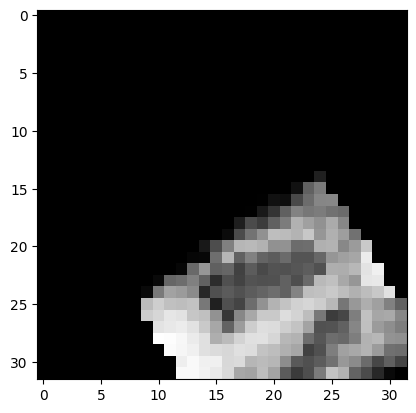

In [ ]:
x_batch, y_batch = next(iter(train_DL))
print(x_batch.shape)
plt.imshow(x_batch[0].permute(1,2,0), cmap='gray')
print(test_DS.classes[y_batch[0]])

- test_DL은 transform가 안걸림

torch.Size([32, 1, 32, 32])
Negative


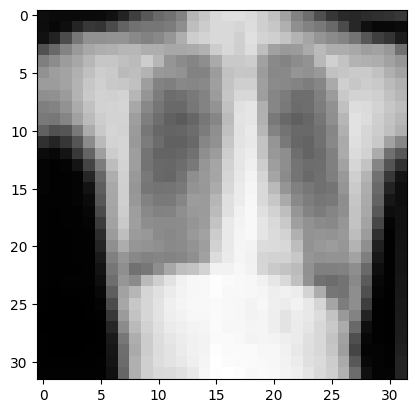

In [ ]:
x_batch, y_batch = next(iter(test_DL))
print(x_batch.shape)
plt.imshow(x_batch[0].permute(1,2,0), cmap='gray')
print(test_DS.classes[y_batch[0]])